final ml with SHAP

In [1]:
!pip install catboost imbalanced-learn lightgbm optuna shap -q

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
import shap
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()

RANDOM_STATE = 42
TARGET_COL = "Churn Value"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 8.0 MB/s eta 0:00:00


In [3]:
from google.colab import files

print("Click 'Choose Files' below and pick your Telco dataset:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"\nUploaded: {filename}")

if filename.endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.endswith((".xlsx", ".xls")):
    df = pd.read_excel(filename)
else:
    raise ValueError("Please upload a .csv, .xlsx, or .xls file")

print(f"\nLoaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Click 'Choose Files' below and pick your Telco dataset:


Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx

Uploaded: Telco_customer_churn.xlsx

Loaded 7043 rows, 33 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
LEAKAGE_AND_ID_COLS = [
    "CustomerID", "Count", "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Score", "Churn Reason",
    "CLTV",  # computed from churn-related signals in this dataset — leakage
]
df = df.drop(columns=[c for c in LEAKAGE_AND_ID_COLS if c in df.columns])
df = df.drop_duplicates()
print(f"After dropping leakage/ID cols and duplicates: {df.shape}\n")

After dropping leakage/ID cols and duplicates: (7021, 20)



In [5]:
data = df.copy()

data["Total Charges"] = pd.to_numeric(data["Total Charges"], errors="coerce").fillna(0)
data["Avg_Monthly_Spend"] = data["Total Charges"] / data["Tenure Months"].replace(0, 1)
data["Charge_Spike"] = data["Monthly Charges"] - data["Avg_Monthly_Spend"]
data["Tenure_Bucket"] = pd.cut(
    data["Tenure Months"], bins=[-1, 6, 12, 24, 48, 100],
    labels=["0-6mo", "6-12mo", "1-2yr", "2-4yr", "4yr+"]
)

service_cols = ["Online Security", "Online Backup", "Device Protection",
                 "Tech Support", "Streaming TV", "Streaming Movies"]
service_cols = [c for c in service_cols if c in data.columns]
data["Num_Services"] = (data[service_cols] == "Yes").sum(axis=1)

if "Contract" in data.columns:
    data["Is_Month_to_Month"] = (data["Contract"] == "Month-to-month").astype(int)

print(f"Added engineered features. New shape: {data.shape}\n")

Added engineered features. New shape: (7021, 25)



In [6]:
cat_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print("Train (balanced):", X_train_bal.shape, " Val:", X_val_scaled.shape, " Test:", X_test_scaled.shape)

Train (balanced): (7228, 24)  Val: (1053, 24)  Test: (1054, 24)


In [7]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "verbosity": -1,
    }
    clf = lgb.LGBMClassifier(**params)
    clf.fit(X_train_bal, y_train_bal)
    proba = clf.predict_proba(X_val_scaled)[:, 1]
    return roc_auc_score(y_val, proba)

print("Tuning LightGBM hyperparameters (this takes a minute)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=False)
print(f"Best validation AUC found: {study.best_value:.3f}")
print(f"Best params: {study.best_params}\n")

Tuning LightGBM hyperparameters (this takes a minute)...
Best validation AUC found: 0.853
Best params: {'n_estimators': 583, 'learning_rate': 0.015607079688702043, 'num_leaves': 27, 'max_depth': 3, 'min_child_samples': 10}



In [8]:
lgbm_clf = lgb.LGBMClassifier(**study.best_params, class_weight="balanced",
                               random_state=RANDOM_STATE, verbosity=-1)
cat_clf = CatBoostClassifier(
    iterations=400, learning_rate=0.03, depth=6,
    auto_class_weights="Balanced", verbose=0, random_state=RANDOM_STATE
)
model = StackingClassifier(
    estimators=[("lgbm", lgbm_clf), ("catboost", cat_clf)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    n_jobs=-1,
)
print("Training final stacked ensemble...")
model.fit(X_train_bal, y_train_bal)
print("Done.\n")

y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
TARGET_RECALL = 0.75
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
precisions, recalls = precisions[:-1], recalls[:-1]
candidates = [(t, p, r) for p, r, t in zip(precisions, recalls, thresholds) if r >= TARGET_RECALL]
best_thresh, best_prec, best_rec = max(candidates, key=lambda x: x[1]) if candidates else (0.5, None, None)
print(f"Tuned threshold (validation) = {best_thresh:.3f}\n")

y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= best_thresh).astype(int)

print("=== FINAL RESULTS — TEST set ===")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_test_pred):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_test_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nFull report:\n", classification_report(y_test, y_test_pred, target_names=["Retained", "Churned"]))

Training final stacked ensemble...
Done.

Tuned threshold (validation) = 0.271

=== FINAL RESULTS — TEST set ===
Accuracy : 0.775
Precision: 0.554
Recall   : 0.774
F1-score : 0.646
AUC-ROC  : 0.868

Confusion Matrix:
 [[601 174]
 [ 63 216]]

Full report:
               precision    recall  f1-score   support

    Retained       0.91      0.78      0.84       775
     Churned       0.55      0.77      0.65       279

    accuracy                           0.78      1054
   macro avg       0.73      0.77      0.74      1054
weighted avg       0.81      0.78      0.79      1054



In [24]:
def stack_predict_proba_class1(X_arr):
    X_df = pd.DataFrame(X_arr, columns=X_train_scaled.columns)
    return model.predict_proba(X_df)[:, 1]

# Reduced background (10-20 points) — prototype speed setting
background_kmeans = shap.kmeans(X_train_scaled, 15)

kernel_explainer = shap.KernelExplainer(stack_predict_proba_class1, background_kmeans)

print("Explainer ready. Background points:", background_kmeans.data.shape[0])

Explainer ready. Background points: 15


In [34]:
def explain_customer(customer_row, nsamples=50,seed=42):
    """
    customer_row: a single-row DataFrame (scaled features) for one customer.
    Returns a shap.Explanation object ready for plotting.
    """
    np.random.seed(seed)
    sv = kernel_explainer.shap_values(customer_row.values, nsamples=nsamples)
    sv = np.array(sv).reshape(1, -1)

    explanation = shap.Explanation(
        values=sv,
        base_values=np.array([kernel_explainer.expected_value]),
        data=customer_row.values,
        feature_names=customer_row.columns.tolist()
    )
    return explanation

# quick smoke test on one customer
test_customer = X_test_scaled.iloc[[0]]
test_explanation = explain_customer(test_customer, nsamples=50)
print("Explain function OK. SHAP values shape:", test_explanation.values.shape)

  0%|          | 0/1 [00:00<?, ?it/s]

Explain function OK. SHAP values shape: (1, 24)


In [35]:
predicted_proba = stack_predict_proba_class1(test_customer.values)[0]
reconstructed = test_explanation.base_values[0] + test_explanation.values[0].sum()

additivity_error = abs(reconstructed - predicted_proba)
print(f"Additivity error at nsamples=50, background=15: {additivity_error:.4f}")

if additivity_error < 0.02:
    print("✅ Still acceptable at the faster settings.")
else:
    print("⚠️ Error grew too much — bump nsamples or background back up.")

Additivity error at nsamples=50, background=15: 0.0000
✅ Still acceptable at the faster settings.


In [36]:
import time

n_repeats = 10
start = time.time()
for _ in range(n_repeats):
    _ = explain_customer(test_customer, nsamples=50)
elapsed_ms = (time.time() - start) / n_repeats * 1000
print(f"Average on-demand latency (nsamples=50, background=15): {elapsed_ms:.2f} ms")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Average on-demand latency (nsamples=50, background=15): 79.41 ms


  0%|          | 0/1 [00:00<?, ?it/s]

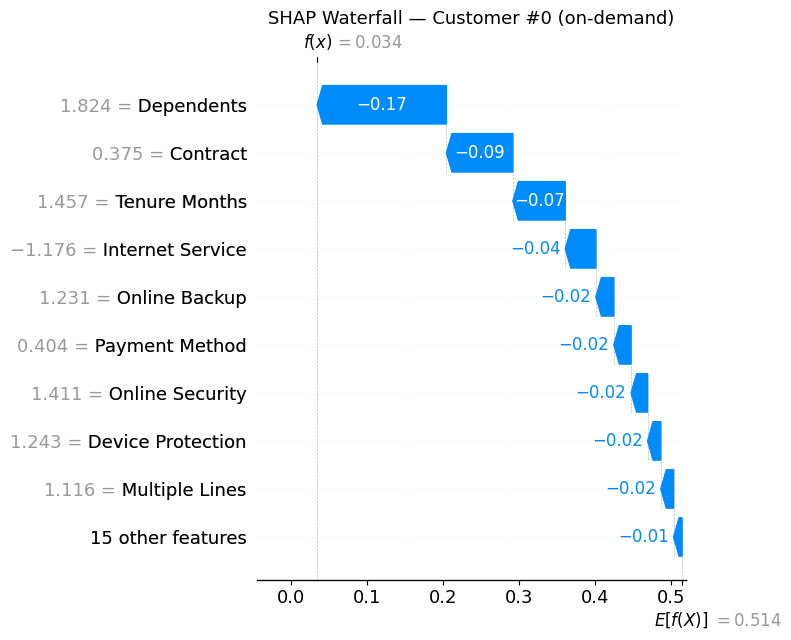

Predicted churn probability: 0.034


In [37]:
CUSTOMER_IDX = 0
customer_row = X_test_scaled.iloc[[CUSTOMER_IDX]]
explanation = explain_customer(customer_row, nsamples=50)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation[0], show=False)
plt.title(f"SHAP Waterfall — Customer #{CUSTOMER_IDX} (on-demand)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Predicted churn probability: {stack_predict_proba_class1(customer_row.values)[0]:.3f}")

In [38]:
HIGH_RISK_THRESHOLD = best_thresh  # reuse your tuned decision threshold from Cell 8

all_test_proba = stack_predict_proba_class1(X_test_scaled.values)
high_risk_mask = all_test_proba >= HIGH_RISK_THRESHOLD
X_high_risk = X_test_scaled[high_risk_mask]

print(f"Total customers: {len(X_test_scaled)} | High-risk: {len(X_high_risk)}")

# Batch SHAP call — one call for all high-risk customers, not one-by-one
shap_values_batch = kernel_explainer.shap_values(X_high_risk.values, nsamples=50)
print("Batch SHAP values shape:", np.array(shap_values_batch).shape)

Total customers: 1054 | High-risk: 390


  0%|          | 0/390 [00:00<?, ?it/s]

Batch SHAP values shape: (390, 24)


In [39]:
high_risk_customer_ids = X_high_risk.index.tolist()

shap_results = pd.DataFrame(
    np.array(shap_values_batch),
    columns=X_high_risk.columns,
    index=high_risk_customer_ids
)
shap_results["churn_probability"] = all_test_proba[high_risk_mask]
shap_results["base_value"] = kernel_explainer.expected_value

print(shap_results.head())

# In your backend, this becomes:
# shap_results.to_sql("shap_explanations", con=your_postgres_engine, if_exists="replace")
# Dashboard then does a SELECT by customer_id instead of recomputing SHAP.

      Gender  Senior Citizen   Partner  Dependents  Tenure Months  \
5204     0.0             0.0  0.055543    0.000000       0.000000   
1655     0.0             0.0 -0.022528    0.025695       0.000000   
4743     0.0             0.0  0.000000    0.016251      -0.140062   
33       0.0             0.0  0.000000   -0.349396       0.175670   
5369     0.0             0.0  0.000000    0.000000       0.059282   

      Phone Service  Multiple Lines  Internet Service  Online Security  \
5204        0.00000        0.053251         -0.122966        -0.089926   
1655        0.00000        0.000000          0.003713         0.000000   
4743        0.00000        0.000000          0.029611         0.000000   
33          0.00000       -0.066298          0.037409         0.000000   
5369        0.03028       -0.077422          0.029430         0.000000   

      Online Backup  ...  Payment Method  Monthly Charges  Total Charges  \
5204      -0.061053  ...        0.000000        -0.033598       

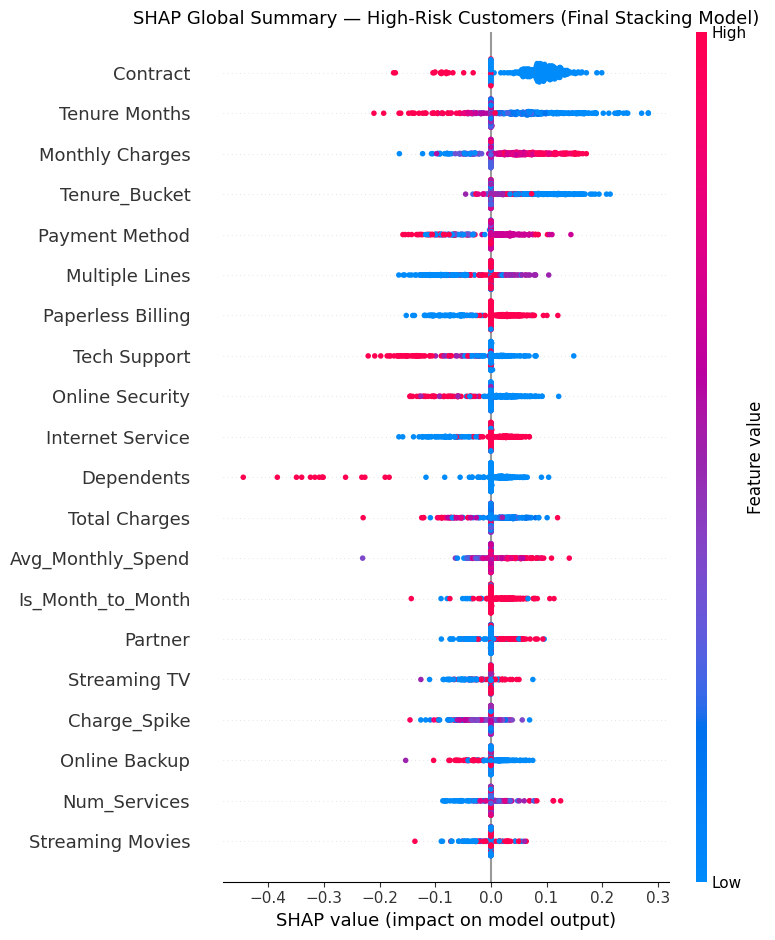

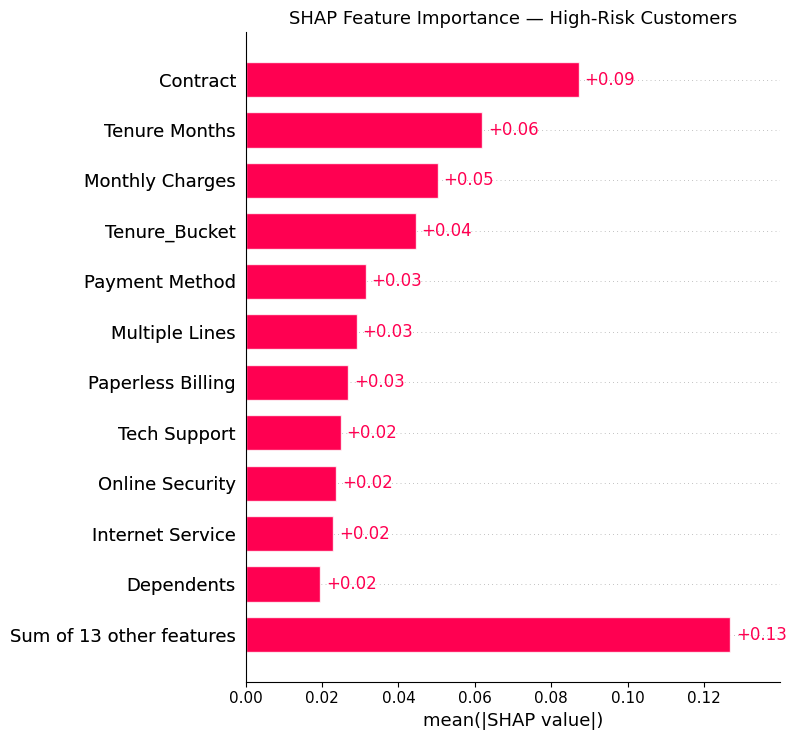

In [40]:
# Wrap the batch results into an Explanation object for plotting
high_risk_explanation = shap.Explanation(
    values=np.array(shap_values_batch),
    base_values=np.full(len(X_high_risk), kernel_explainer.expected_value),
    data=X_high_risk.values,
    feature_names=X_high_risk.columns.tolist()
)

# A. Global summary (beeswarm) — direction + magnitude of each feature's effect
plt.figure(figsize=(10, 6))
shap.summary_plot(high_risk_explanation, X_high_risk, show=False)
plt.title("SHAP Global Summary — High-Risk Customers (Final Stacking Model)", fontsize=13)
plt.tight_layout()
plt.show()

# B. Global feature importance (bar) — ranked by mean |SHAP value|
plt.figure(figsize=(10, 6))
shap.plots.bar(high_risk_explanation, max_display=12, show=False)
plt.title("SHAP Feature Importance — High-Risk Customers", fontsize=13)
plt.tight_layout()
plt.show()